In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

with open('rename_tbl.pkl', 'rb') as f:
    rename_tbl = pickle.load(f)

def get_linestyle(source):
    if source.startswith('cf'):
        return 'solid'
    elif source.startswith('fb'):
        return 'dashed'
    elif source.startswith('wm'):
        return 'dotted'
    return 'solid'

import matplotlib.pylab as pylab
pylab.rcParams.update({
    'legend.fontsize': 'large',
    'figure.figsize': (6, 4),
    'axes.labelsize': 'large',
    'axes.titlesize': 'large',
    'xtick.labelsize': 'large',
    'ytick.labelsize': 'large',
})

# Latency model: every hit costs HIT_MS, every miss costs MISS_MS.
HIT_MS = 10
MISS_MS = 150

## Load runs and derive latency / overhead
Same input files as `sim_results.ipynb`'s ML tradeoff section. The latency column is computed by weighing each request by `HIT_MS` or `MISS_MS`.

In [3]:
r10files = [
    '../results/r10i1_baseline.csv',
    '../results/r10i1_oracle.csv',
    '../results/r10i1_ml_cf_rfc.csv',
    '../results/r10i1_ml_fb_rfc.csv',
    '../results/r10i1_ml_wm_rfc.csv',
    '../results/r10i1_ml_wm_rfc_extended.csv',
    '../results/r10i1_ml_fb_rfc_extended2.csv',
    '../results/r10i1_ml_wm_rfc_extended2.csv',
]
df = pd.concat([pd.read_csv(f) for f in r10files])
df = df.drop(columns=['rv_min_ttl', 'rv_min_freq', 'rv_max_za'])
df = df.drop_duplicates().sort_values(by=['mode', 'in', 'cache_type', 'mlthres'])
df['trace'] = df['in'].map(rename_tbl).fillna(df['in'])

df['hit_all'] = df['hit_fresh'] + df['hit_reval'] + df['hit_stale']
df['miss_all'] = df.miss_mandatory + df.miss_expired + df.miss_evicted
df['hit_rate'] = df['hit_all'] / df['all']
df['miss_rate'] = df['miss_all'] / df['all']

# Overhead (origin amplification): same definition used in sim_results.ipynb.
df['rv_pending'] = df.revals - df.hit_reval - df.reval_wasted
df['amp_lower'] = df['reval_wasted'] / (df['miss_all'] + df['hit_reval']) + 1
df['amp_upper'] = (df['reval_wasted'] + df['rv_pending']) / (df['miss_all'] + df['hit_reval']) + 1
df['amp_avg']   = (df['amp_lower'] + df['amp_upper']) / 2
df['overhead_pct'] = (df['amp_avg'] - 1) * 100

# Average per-request latency under the simple hit/miss latency model.
df['avg_latency_ms'] = df['hit_rate'] * HIT_MS + df['miss_rate'] * MISS_MS
df[['in', 'trace', 'mode', 'cache_type', 'mlthres', 'hit_rate', 'overhead_pct', 'avg_latency_ms']].head()

,in,trace,mode,cache_type,mlthres,hit_rate,overhead_pct,avg_latency_ms
35,cf_a,BOS 1,ml,arc,0.66,0.901099,9.897105,23.846206
36,cf_a,BOS 1,ml,arc,0.68,0.900394,3.539994,23.944787
34,cf_a,BOS 1,ml,arc,0.70,0.899621,2.745554,24.053092
32,cf_a,BOS 1,ml,arc,0.75,0.898132,1.491856,24.261519
30,cf_a,BOS 1,ml,arc,0.80,0.896977,0.899912,24.423258


## Latency improvement vs. overhead — per trace
Two panels:
- **(a)** absolute latency reduction in ms vs. baseline (`never` mode on the same trace and cache type).
- **(b)** relative latency reduction as % of baseline latency.

X-axis is overhead % = (avg origin amplification − 1) × 100, matching `sim_results.ipynb`.

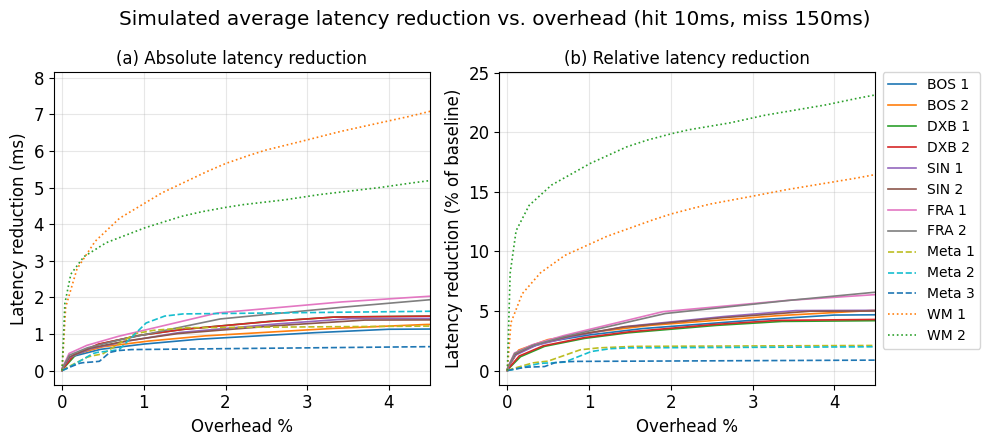

In [ ]:
mldf = df[((df['mode'] == 'ml') | (df['mode'] == 'never')) & (df['cache_type'] == 'lru')]
traces_sorted = sorted(mldf['in'].unique())

# Baseline latency per trace = avg_latency_ms of the corresponding `never` run.
baseline_lat = (df[(df['mode'] == 'never') & (df['cache_type'] == 'lru')]
                .set_index('in')['avg_latency_ms'])

fig, axs = plt.subplots(1, 2, figsize=(10, 4.5))
for i in traces_sorted:
    label = rename_tbl.get(i, i)
    base = baseline_lat.loc[i]
    sub = mldf[(mldf['in'] == i) & (mldf['mode'] == 'ml')].sort_values(by='amp_avg')
    lat_red_ms = base - sub['avg_latency_ms']
    lat_red_pct = lat_red_ms / base * 100
    ls = get_linestyle(i)
    axs[0].plot(sub['overhead_pct'], lat_red_ms, marker='', linewidth=1.2, label=label, linestyle=ls)
    axs[1].plot(sub['overhead_pct'], lat_red_pct, marker='', linewidth=1.2, label=label, linestyle=ls)

for ax in axs:
    ax.set_xlim(-0.1, 4.5)
    ax.set_xlabel('Overhead %')
    ax.grid(True, alpha=0.3)
axs[0].set_ylabel('Latency reduction (ms)')
axs[0].set_title(f'(a) Absolute latency reduction')
axs[1].set_ylabel('Latency reduction (% of baseline)')
axs[1].set_title('(b) Relative latency reduction')
axs[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize='medium')
fig.suptitle(f'Simulated average latency reduction vs. overhead (hit {HIT_MS}ms, miss {MISS_MS}ms)', fontsize='x-large')
plt.tight_layout()

## Single combined view
Just the relative latency improvement vs. overhead — the headline tradeoff curve.

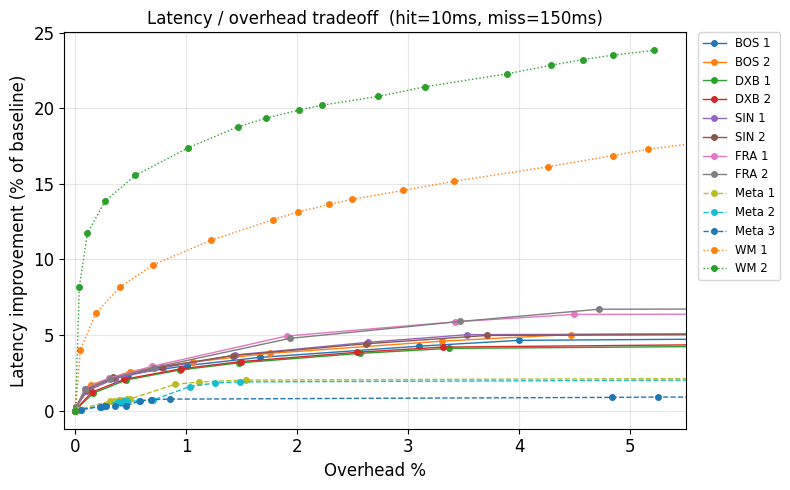

In [4]:
plt.figure(figsize=(8, 5))
for i in traces_sorted:
    label = rename_tbl.get(i, i)
    base = baseline_lat.loc[i]
    sub = mldf[(mldf['in'] == i) & (mldf['mode'] == 'ml')].sort_values(by='amp_avg')
    lat_red_pct = (base - sub['avg_latency_ms']) / base * 100
    plt.plot(sub['overhead_pct'], lat_red_pct, marker='o', ms=4, linewidth=1, label=label, linestyle=get_linestyle(i))

plt.xlim(-0.1, 5.5)
plt.xlabel('Overhead %')
plt.ylabel('Latency improvement (% of baseline)')
plt.title(f'Latency / overhead tradeoff  (hit={HIT_MS}ms, miss={MISS_MS}ms)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()

## Sensitivity: how does the curve change if you tune the hit/miss latencies?
Same x-axis, but recompute `avg_latency_ms` for a few (hit_ms, miss_ms) settings. The qualitative shape stays the same because latency improvement is `(miss_ms − hit_ms) × hit_rate_delta` — only the ratio matters.

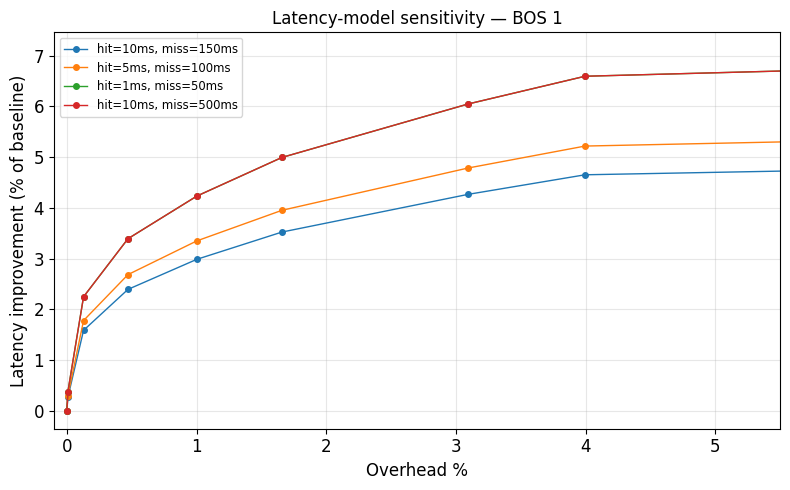

In [5]:
scenarios = [(10, 150), (5, 100), (1, 50), (10, 500)]
focus_trace = 'cf_a'  # change to inspect a different trace
sub = mldf[(mldf['in'] == focus_trace) & (mldf['mode'] == 'ml')].sort_values(by='amp_avg')
base_hit_rate = df[(df['mode'] == 'never') & (df['cache_type'] == 'lru') & (df['in'] == focus_trace)]['hit_rate'].values[0]

plt.figure(figsize=(8, 5))
for hit_ms, miss_ms in scenarios:
    base = base_hit_rate * hit_ms + (1 - base_hit_rate) * miss_ms
    ml_lat = sub['hit_rate'] * hit_ms + (1 - sub['hit_rate']) * miss_ms
    plt.plot(sub['overhead_pct'], (base - ml_lat) / base * 100,
             marker='o', ms=4, linewidth=1, label=f'hit={hit_ms}ms, miss={miss_ms}ms')

plt.xlim(-0.1, 5.5)
plt.xlabel('Overhead %')
plt.ylabel('Latency improvement (% of baseline)')
plt.title(f'Latency-model sensitivity — {rename_tbl.get(focus_trace, focus_trace)}')
plt.legend(loc='best', fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()

## Latency improvement vs. overhead — absolute ms
Y-axis is `baseline_latency_ms − avg_latency_ms` for the same trace's `never` run, so 0 is the baseline and **positive means faster than baseline (ms saved per request)**.

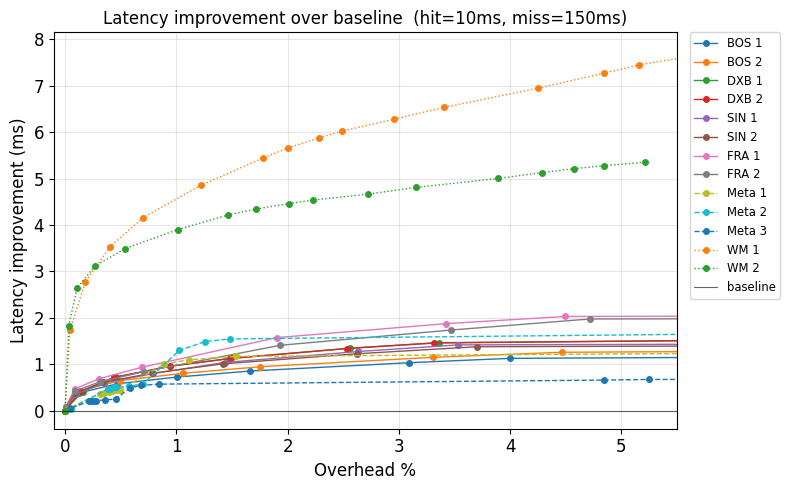

In [6]:
plt.figure(figsize=(8, 5))
for i in traces_sorted:
    label = rename_tbl.get(i, i)
    base = baseline_lat.loc[i]
    sub = mldf[(mldf['in'] == i) & (mldf['mode'] == 'ml')].sort_values(by='amp_avg')
    improvement_ms = base - sub['avg_latency_ms']  # positive = faster than baseline
    plt.plot(sub['overhead_pct'], improvement_ms, marker='o', ms=4, linewidth=1,
             label=label, linestyle=get_linestyle(i))

plt.axhline(0, color='black', linewidth=0.8, alpha=0.6, label='baseline')
plt.xlim(-0.1, 5.5)
plt.xlabel('Overhead %')
plt.ylabel('Latency improvement (ms)')
plt.title(f'Latency improvement over baseline  (hit={HIT_MS}ms, miss={MISS_MS}ms)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize='small')
plt.grid(True, alpha=0.3)
plt.tight_layout()

## Absolute latency in ms
Per-trace `avg_latency_ms` plotted against overhead, with each trace's `never`-mode baseline drawn as a dashed reference line of the same color. Useful when the raw ms response time matters (not just the delta vs. baseline).

,baseline_ms,avg_latency_ms,improvement_ms,improvement_pct,overhead_pct,mlthres
trace,,,,,,
BOS 1,24.24,23.03,1.22,5.01,11.48,0.66
Meta 1,57.80,56.63,1.17,2.03,1.54,0.82
Meta 1,57.80,57.35,0.45,0.78,0.49,0.85
WM 1,43.10,37.22,5.88,13.64,2.28,0.66
BOS 2,24.99,23.63,1.36,5.44,12.80,0.66
WM 2,22.45,17.99,4.46,19.88,2.01,0.66
Meta 3,74.81,74.81,0.00,0.00,0.00,1.00
DXB 1,35.56,33.97,1.59,4.47,9.86,0.66
DXB 2,34.68,33.10,1.57,4.54,8.34,0.66


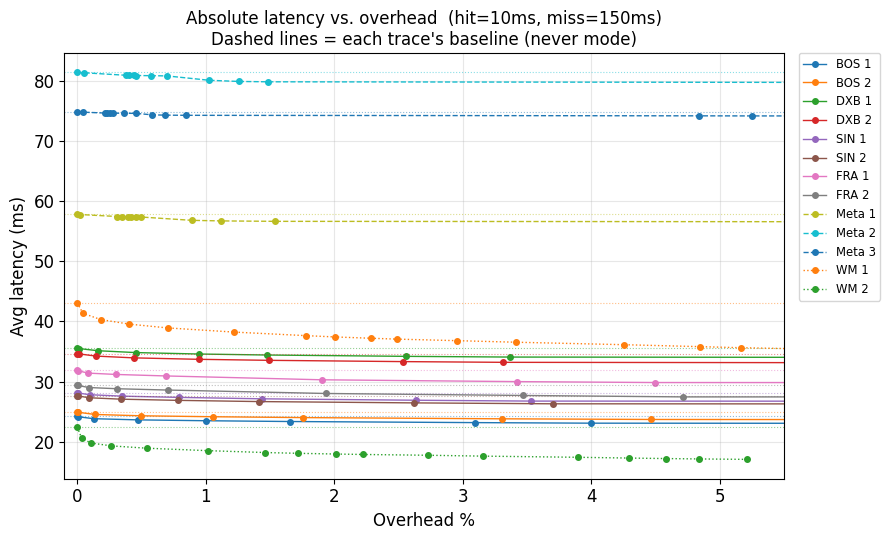

In [7]:
fig, ax = plt.subplots(figsize=(9, 5.5))
cmap = plt.get_cmap('tab10')
trace_color = {tr: cmap(i % 10) for i, tr in enumerate(traces_sorted)}

for i in traces_sorted:
    label = rename_tbl.get(i, i)
    base = baseline_lat.loc[i]
    sub = mldf[(mldf['in'] == i) & (mldf['mode'] == 'ml')].sort_values(by='amp_avg')
    color = trace_color[i]
    ax.plot(sub['overhead_pct'], sub['avg_latency_ms'], marker='o', ms=4, linewidth=1,
            label=label, color=color, linestyle=get_linestyle(i))
    ax.axhline(base, color=color, linewidth=0.8, alpha=0.5, linestyle=':')

ax.set_xlim(-0.1, 5.5)
ax.set_xlabel('Overhead %')
ax.set_ylabel('Avg latency (ms)')
ax.set_title(f'Absolute latency vs. overhead  (hit={HIT_MS}ms, miss={MISS_MS}ms)\nDashed lines = each trace\'s baseline (never mode)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., fontsize='small')
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Table view: baseline vs best-latency ML config per trace.
best_idx = mldf[mldf['mode'] == 'ml'].groupby('in')['avg_latency_ms'].idxmin()
best = mldf.loc[best_idx, ['in', 'mlthres', 'overhead_pct', 'avg_latency_ms']].copy()
best['baseline_ms'] = best['in'].map(baseline_lat)
best['improvement_ms'] = best['baseline_ms'] - best['avg_latency_ms']
best['improvement_pct'] = best['improvement_ms'] / best['baseline_ms'] * 100
best['trace'] = best['in'].map(rename_tbl).fillna(best['in'])
best.set_index('trace')[['baseline_ms', 'avg_latency_ms', 'improvement_ms', 'improvement_pct', 'overhead_pct', 'mlthres']].round(2)